# Monitor do Optuna — visualizar studies rodando no cluster

Este notebook puxa o SQLite do study do cluster e gera o `show_optuna_snapshot` (estilo orientador) e outros plots.

## Como usar

1. Submeta um job no cluster (LRG ou ELG) com `sbatch --export=ALL,OBJ=LRG ...`.
2. Aguarde uns minutos pra o primeiro trial completar (o SQLite só nasce quando o study começa).
3. Rode este notebook **inteiro** (Cell > Run All), ou apenas a célula de sync + a do snapshot.
4. Pra atualizar, reroda a célula de sync e a do snapshot.

Diferente do `optuna-dashboard`, este notebook **não é tempo real automático** — ele tira uma "foto" do study cada vez que você reroda. Vantagem: simples, não precisa de port-forward nem instalar nada novo.

In [1]:
# ============================================================
# PAPERMILL PARAMETERS
# ============================================================
# OBJECT_TYPE: qual objeto. STUDY_KIND: qual job Optuna acompanhar.
#   "flex"    -> results/<OBJ>/cnn_optuna_flex/optuna_study.db    (o principal)
#   "simples" -> results/<OBJ>/cnn_optuna_simples/optuna_study.db (legado)
# STUDY_NAME = None -> auto-descobre o study mais recente no .db (nao precisa do hash).

OBJECT_TYPE = "LRG"     # "LRG" | "ELG" | "QSO"
STUDY_KIND  = "flex"    # "flex" | "simples"
STUDY_NAME  = None      # None = auto (study com trial mais recente); ou fixe o nome


In [2]:
# ============================================================
# IMPORTS E PATHS
# ============================================================
import sys, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import optuna

# Descobre PROJECT_ROOT (onde tem config.py)
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "config.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Subdiretorio do .db por tipo de study.
_SUBDIR = {"flex": "cnn_optuna_flex", "simples": "cnn_optuna_simples"}
if STUDY_KIND not in _SUBDIR:
    raise ValueError(f"STUDY_KIND invalido: {STUDY_KIND}. Use {list(_SUBDIR)}.")

# Caminho relativo (mesmo string local e remoto).
DB_REL      = Path("results") / OBJECT_TYPE / _SUBDIR[STUDY_KIND] / "optuna_study.db"
DB_PATH     = PROJECT_ROOT / DB_REL
STORAGE_URL = f"sqlite:///{DB_PATH}"

print(f"Project root : {PROJECT_ROOT}")
print(f"Objeto       : {OBJECT_TYPE}  | kind: {STUDY_KIND}")
print(f"DB path      : {DB_PATH}")
print(f"Study name   : {STUDY_NAME or '(auto)'}")


Project root : /home/thalita/spec_z_ml
DB path      : /home/thalita/spec_z_ml/results/LRG/cnn_optuna_simples/optuna_study.db
Study name   : cnn_simples_LRG


## 1. Sincronizar o SQLite do cluster

Puxa só o arquivo `.db` (não baixa modelos nem plots pesados, fica rápido). Usa rsync direto via subprocess.

In [6]:
# ============================================================
# SYNC DO SQLITE
# ============================================================
# Configuracao do remoto (mesmo do sync_to_cluster.sh)
REMOTE_USER = "valerio"
REMOTE_HOST = "172.20.76.10"
REMOTE_DIR  = "/home/valerio/Thalita/spec_z_ml"

# Mesmo caminho relativo definido acima (DB_REL) -> nunca sai de sincronia.
REMOTE_DB = f"{REMOTE_USER}@{REMOTE_HOST}:{REMOTE_DIR}/{DB_REL.as_posix()}"

# Garante pasta local
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Puxando: {REMOTE_DB}")
print(f"   para: {DB_PATH}\n")

# rsync -az (archive + compress); -h human readable; --partial pra retomar se cair
result = subprocess.run(
    ["rsync", "-azh", "--partial", "--progress",
     REMOTE_DB, str(DB_PATH)],
    capture_output=True, text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("=" * 60)
    print("ERRO no rsync:")
    print(result.stderr)
    print("=" * 60)
    print("\nMotivos comuns:")
    print(" - O job ainda nao criou o .db (espera o primeiro trial completar).")
    print(" - SSH pedindo senha — configure chave SSH (ssh-copy-id) ou rode o")
    print("   rsync manualmente no terminal antes deste notebook.")
else:
    size_kb = DB_PATH.stat().st_size / 1024 if DB_PATH.exists() else 0
    print(f"OK. Arquivo local: {DB_PATH} ({size_kb:.1f} KB)")


Puxando: valerio@172.20.76.10:/home/valerio/Thalita/spec_z_ml/results/LRG/cnn_optuna_simples/optuna_study.db
   para: /home/thalita/spec_z_ml/results/LRG/cnn_optuna_simples/optuna_study.db

receiving incremental file list
optuna_study.db

              0   0%    0,00kB/s    0:00:00  
        167,94K 100%  160,16MB/s    0:00:00 (xfr#1, to-chk=0/1)

OK. Arquivo local: /home/thalita/spec_z_ml/results/LRG/cnn_optuna_simples/optuna_study.db (164.0 KB)


## 2. Carregar o study do SQLite

In [7]:
# ============================================================
# CARREGAR STUDY (auto-descobre o nome se STUDY_NAME=None)
# ============================================================
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DB nao existe localmente: {DB_PATH}\n"
        "Roda a celula de sync primeiro, e confirma que o job no cluster ja gerou trials."
    )

# Um .db pode conter VARIOS studies (1 por config_hash). Lista todos.
all_names = optuna.get_all_study_names(storage=STORAGE_URL)
if not all_names:
    raise ValueError(f"Nenhum study no .db ({DB_PATH}). O job ja' comecou?")


def _last_start(nm):
    st = optuna.load_study(study_name=nm, storage=STORAGE_URL)
    ts = [t.datetime_start for t in st.trials if t.datetime_start]
    return (st, max(ts) if ts else None)


print(f"Studies no .db ({len(all_names)}):")
info = {}
for nm in all_names:
    st, last = _last_start(nm)
    info[nm] = (st, last)
    when = last.strftime("%Y-%m-%d %H:%M") if last else "sem trials"
    print(f"  - {nm}  ({len(st.trials)} trials, ultimo: {when})")

if STUDY_NAME is None:
    # escolhe o study com o trial mais recente (= o run que esta rodando agora)
    cand = [(nm, last) for nm, (_, last) in info.items() if last is not None]
    STUDY_NAME = (max(cand, key=lambda x: x[1])[0] if cand else all_names[-1])
    print(f"\n[auto] study mais recente: {STUDY_NAME}")

study = info[STUDY_NAME][0] if STUDY_NAME in info else optuna.load_study(
    study_name=STUDY_NAME, storage=STORAGE_URL)

states = pd.Series([t.state.name for t in study.trials]).value_counts().to_dict()
print(f"\nStudy     : {STUDY_NAME}")
print(f"Direction : {study.direction.name}")
print(f"# trials  : {len(study.trials)}")
print(f"Estados   : {states}")

try:
    print(f"Best value: {study.best_value:.5f}  (trial #{study.best_trial.number})")
    print("Best params:")
    for k, v in study.best_params.items():
        print(f"  {k:>16s} = {v}")
except Exception as e:
    print(f"Sem best ainda: {type(e).__name__}")


Study     : cnn_simples_LRG
Direction : MINIMIZE
# trials  : 46
Estados   : {'COMPLETE': 31, 'PRUNED': 14, 'RUNNING': 1}
Best value: 0.02005  (trial #31)
Best params:
     learning_rate = 0.0004938704868514536
      dropout_rate = 0.10023850711801861
        batch_size = 32
       kernel_size = 21


## 3. `show_optuna_snapshot` (versão do orientador)

Distingue visualmente trials completos / podados / falhos, mostra best-so-far e zoom em torno do melhor valor.

State counts: {'COMPLETE': 31, 'PRUNED': 14, 'RUNNING': 1}
Total trials: 46
Completed (finite) trials: 31
Current best value: 0.02005084790289402
Best trial number: 31

Last 10 completed (finite) trials:


number,value
29,0.025378
31,0.020051
32,0.020863
33,0.020518
34,0.027687
35,0.021325
37,0.020741
41,0.020553
42,0.020334
43,0.020268


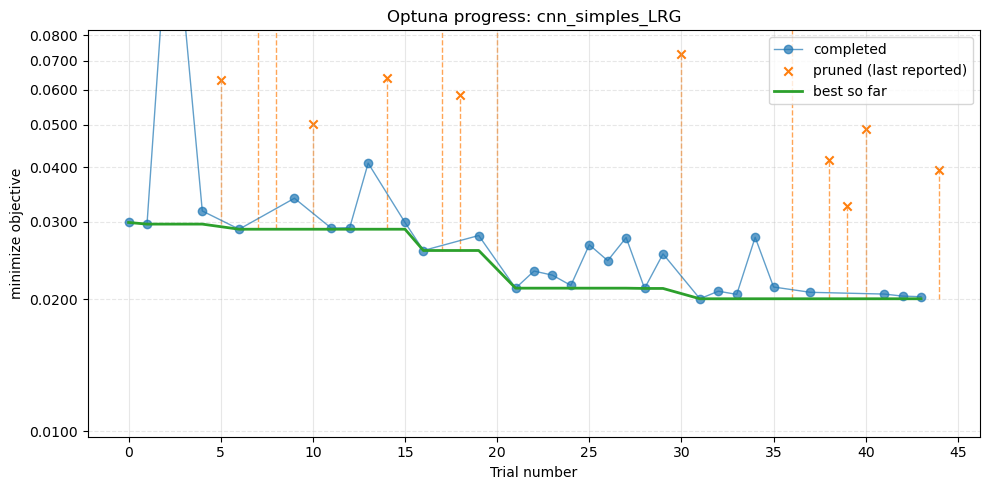

In [8]:
def show_optuna_snapshot(
    study,
    run_name=None,
    save_path=None,
    last_n=10,
    robust_scale_fn=None,
    y_min_scale=0.5,
    y_max_scale=3.0,
    show_table=True,
):
    """Snapshot do Optuna mostrando trials completos, podados e falhos."""

    def load_optuna_trials_df(study):
        df = study.trials_dataframe(
            attrs=("number", "state", "value", "datetime_start", "datetime_complete")
        )
        if df.empty:
            return df
        return df.sort_values("number").reset_index(drop=True)

    df = load_optuna_trials_df(study)
    if df.empty:
        print("No trials yet.")
        return {"df": df, "df_completed": df, "x": np.array([], dtype=int),
                "vals": np.array([], dtype=float), "fig": None, "ax": None}

    state_counts = df["state"].astype(str).value_counts().to_dict()
    print("State counts:", state_counts)
    print("Total trials:", len(df))

    trial_numbers = np.array([t.number for t in study.trials], dtype=int)
    trial_values = np.array([
        t.value if t.value is not None and np.isfinite(t.value) else np.nan
        for t in study.trials
    ])
    trial_states = np.array([t.state.name for t in study.trials])

    mask_complete = (trial_states == "COMPLETE") & np.isfinite(trial_values)
    mask_pruned   = (trial_states == "PRUNED")
    mask_fail     = (trial_states == "FAIL")

    x_completed = trial_numbers[mask_complete]
    vals_completed = trial_values[mask_complete]

    if len(vals_completed) == 0:
        print("No completed finite trials yet.")
        return {"df": df, "df_completed": df.iloc[0:0],
                "x": np.array([], dtype=int), "vals": np.array([], dtype=float),
                "fig": None, "ax": None}

    direction = study.direction.name
    is_minimize = direction == "MINIMIZE"
    best_idx = int(np.argmin(vals_completed) if is_minimize else np.argmax(vals_completed))
    best_value = float(vals_completed[best_idx])
    best_trial_number = int(x_completed[best_idx])

    print("Completed (finite) trials:", len(vals_completed))
    print("Current best value:", best_value)
    print("Best trial number:", best_trial_number)

    df_completed = df[(df["state"] == "COMPLETE") & (df["value"].notna())
                      & np.isfinite(df["value"].astype(float))].copy()

    if show_table:
        try:
            from IPython.display import display
            print(f"\nLast {last_n} completed (finite) trials:")
            display(df_completed[["number", "value"]].tail(last_n).reset_index(drop=True)
                    .style.hide(axis="index"))
        except Exception:
            print(df_completed[["number", "value"]].tail(last_n).to_string(index=False))

    best_so_far = (np.minimum.accumulate(vals_completed) if is_minimize
                   else np.maximum.accumulate(vals_completed))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_completed, vals_completed, marker="o", lw=1, alpha=0.7,
            label="completed", color="tab:blue")

    pruned_x, pruned_y = [], []
    for t in study.trials:
        if t.state.name == "PRUNED" and t.intermediate_values:
            last_step = max(t.intermediate_values)
            pruned_x.append(t.number)
            pruned_y.append(t.intermediate_values[last_step])
    if pruned_x:
        ax.scatter(pruned_x, pruned_y, marker="x", color="tab:orange",
                   label="pruned (last reported)")
        for x, y in zip(pruned_x, pruned_y):
            mask_before = x_completed < x
            if np.any(mask_before):
                best_before = (np.min(vals_completed[mask_before]) if is_minimize
                               else np.max(vals_completed[mask_before]))
            else:
                best_before = y
            ax.vlines(x, best_before, y, color="tab:orange", lw=1, alpha=0.7,
                      linestyle="--", zorder=0)

    if np.any(mask_fail):
        ax.scatter(trial_numbers[mask_fail],
                   np.full(np.sum(mask_fail), np.nanmin(vals_completed)),
                   marker="*", color="tab:red", label="failed")

    ax.plot(x_completed, best_so_far, lw=2, label="best so far", color="tab:green")

    ax.set_xlabel("Trial number")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylabel(f"{direction.lower()} objective")
    ax.set_title(f"Optuna progress: {run_name or study.study_name}")

    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, subs=list(np.arange(1, 10) * 0.1), numticks=10))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.grid(True, axis="x", which="major", alpha=0.3)
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=list(np.arange(2, 10) * 0.1)))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, axis="y", which="both", alpha=0.3, linestyle="--")

    scale = float(robust_scale_fn(vals_completed)) if robust_scale_fn is not None else float(np.std(vals_completed))
    if not np.isfinite(scale) or scale <= 0:
        scale = max(1e-8, abs(best_value) * 0.05)
    y_min = best_value - y_min_scale * scale
    y_max = best_value + y_max_scale * scale
    if y_min <= 0:
        positive_vals = vals_completed[vals_completed > 0]
        y_min = float(np.min(positive_vals)) * 0.95 if positive_vals.size else max(1e-8, y_max * 1e-3)
    if y_max <= y_min:
        y_max = y_min * 1.1
    ax.set_ylim(y_min, y_max)
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return {"df": df, "df_completed": df_completed,
            "x": x_completed, "vals": vals_completed, "fig": fig, "ax": ax}


# Rodar
_ = show_optuna_snapshot(study, run_name=STUDY_NAME, last_n=10)

## 4. Importância dos hiperparâmetros

Quanto cada HP "explica" da variância dos val_MAE entre trials. Útil pra discussão no TCC.

In [ ]:
try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    values = list(importances.values())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(names, values, color="coral", edgecolor="black", lw=0.5)
    ax.set_xlabel("Importancia relativa")
    ax.set_title(f"Importancia dos HPs — {STUDY_NAME}")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nValores:")
    for n, v in importances.items():
        print(f"  {n:>16s} = {v:.4f}")
except Exception as e:
    print(f"Importances indisponivel (provavelmente poucos trials): {type(e).__name__}: {e}")

## 5. Tabela com top-N trials

In [ ]:
df = study.trials_dataframe()
df_complete = df[df["state"] == "COMPLETE"].copy()
df_complete = df_complete.sort_values("value").head(10)

# So as colunas uteis
cols_keep = ["number", "value", "state"] + [c for c in df_complete.columns if c.startswith("params_")]
df_complete = df_complete[cols_keep].reset_index(drop=True)
df_complete.columns = [c.replace("params_", "") for c in df_complete.columns]

print("Top 10 trials (menor val_MAE primeiro):")
df_complete.round(5)